<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB9 — CNN Architectures for Medical Imaging + Grad-CAM XAI — PneumoniaMNIST · ResNet-style vs Custom CNN · Layer Depth Experiments</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 3 | Prof. Dr. Utku Kose | Universidad Panamericana</p><p style="color:#D0E4F4;margin:2px 0 0;font-size:0.9em">Datasets: PneumoniaMNIST (chest X-ray binary classification, 28×28 grayscale)</p></div>

## Learning Objectives

- Understand the **convolutional operation** and how depth creates hierarchical features
- Train two CNN architectures (lightweight custom vs ResNet-inspired) and compare
- Apply **Grad-CAM** at different convolutional layers to see how explanations change with depth
- Run controlled experiments: **filter count**, **kernel size**, **depth** sweeps
- Learn the critical clinical rule: CNN without Grad-CAM validation = **undeployable**

| Section | Topic |
|---|---|
| 1 | Data loading + visualisation (PneumoniaMNIST) |
| 2 | Custom CNN architecture + training |
| 3 | Architecture comparison: depth & filter sweeps |
| 4 | Grad-CAM implementation from scratch |
| 5 | Layer-by-layer Grad-CAM: what does each layer 'see'? |
| 6 | Critical facts: spurious correlations + the Grad-CAM audit protocol |

> ⚕️ **Why PneumoniaMNIST?** It is a realistic binary classification task (pneumonia vs normal)
> derived from real chest X-rays, small enough to train in minutes on CPU, yet reproduces
> the key challenges of clinical imaging AI.


## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from matplotlib.colors import Normalize
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, classification_report
import time

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
NAVY='#1F3864'; BLUE='#2E75B6'; GREEN='#27AE60'; RED='#E84855'

torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ── Load PneumoniaMNIST ──────────────────────────────────────────────────────
try:
    import medmnist
    from medmnist import PneumoniaMNIST
    train_dataset = PneumoniaMNIST(split='train', download=True, size=28)
    test_dataset  = PneumoniaMNIST(split='test',  download=True, size=28)
    
    def to_tensors(ds):
        imgs  = torch.tensor(np.stack([np.array(item[0]) for item in ds]), dtype=torch.float32)
        imgs  = imgs.unsqueeze(1) / 255.0  # (N,1,28,28)
        labels = torch.tensor([int(item[1]) for item in ds], dtype=torch.float32)
        return imgs, labels
    
    X_tr, y_tr = to_tensors(train_dataset)
    X_te, y_te = to_tensors(test_dataset)
except Exception as e:
    print(f"medmnist not available ({e}) — generating synthetic chest X-ray-like data")
    np.random.seed(42)
    n_tr, n_te = 3000, 500
    # Simulate: pneumonia = bright central region (consolidation pattern)
    def make_xray(n, positive_frac=0.5):
        imgs = np.random.rand(n, 1, 28, 28).astype(np.float32) * 0.3
        labels = (np.random.rand(n) < positive_frac).astype(np.float32)
        for i, lbl in enumerate(labels):
            if lbl == 1:  # pneumonia: bright patch in lower-right (typical consolidation)
                imgs[i, 0, 14:24, 14:24] += np.random.rand(10,10)*0.6 + 0.2
            else:  # normal: uniform with rib-like horizontal bands
                imgs[i, 0, ::4, :] += 0.15
        return np.clip(imgs, 0, 1), labels
    X_tr_np, y_tr_np = make_xray(n_tr)
    X_te_np, y_te_np = make_xray(n_te)
    X_tr, y_tr = torch.tensor(X_tr_np), torch.tensor(y_tr_np)
    X_te, y_te = torch.tensor(X_te_np), torch.tensor(y_te_np)

print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")
print(f"Positive rate — Train: {y_tr.mean():.1%}  Test: {y_te.mean():.1%}")

# DataLoaders
tr_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
te_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=128, shuffle=False)


Device: cpu
Train: torch.Size([4708, 1, 28, 28])  |  Test: torch.Size([624, 1, 28, 28])
Positive rate — Train: 74.2%  Test: 62.5%


---
## Section 1 — Data Visualisation — Chest X-Ray Patterns
🗂 **PneumoniaMNIST**



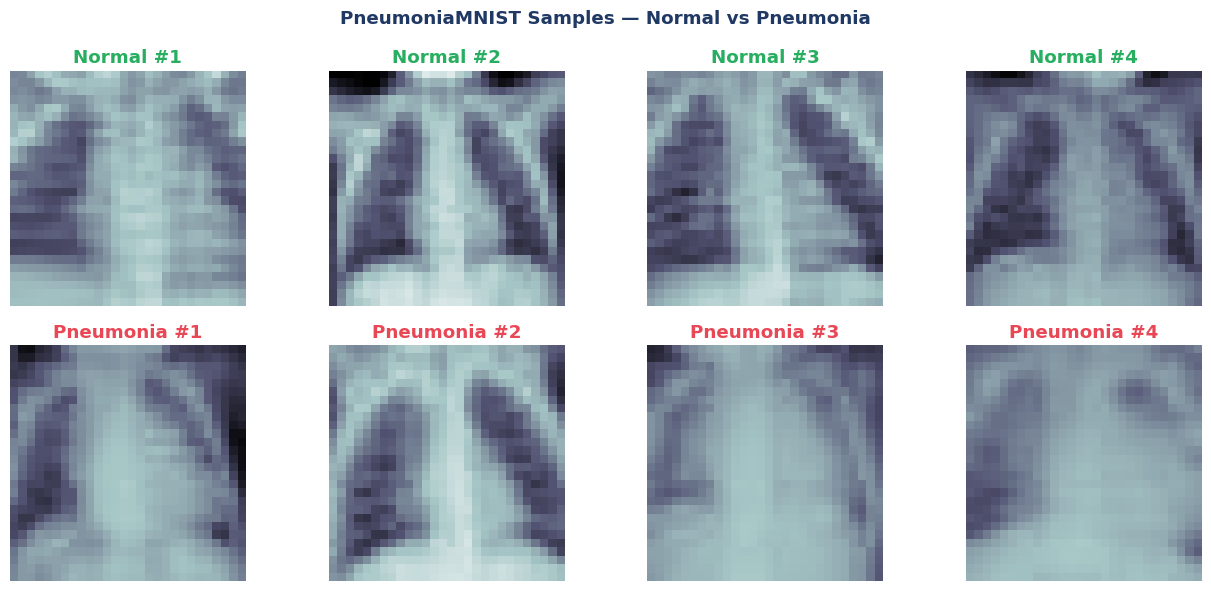

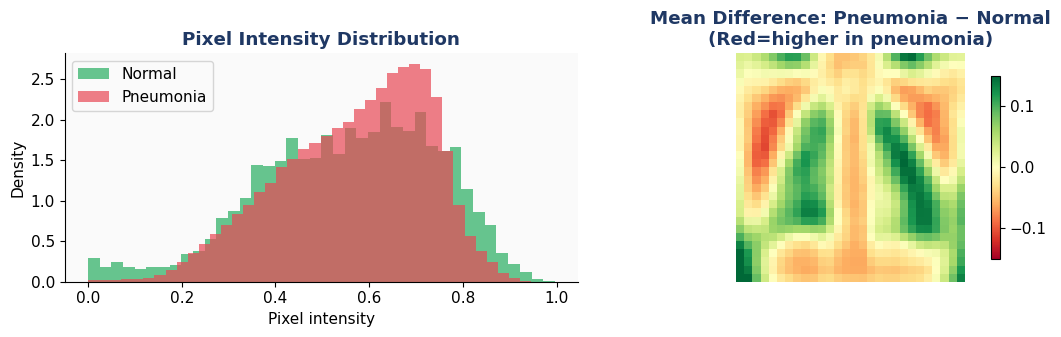

In [2]:
# ── Show sample images ────────────────────────────────────────────────────────
normal_idx  = (y_te == 0).nonzero().squeeze()[:4]
pneum_idx   = (y_te == 1).nonzero().squeeze()[:4]

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
fig.suptitle("PneumoniaMNIST Samples — Normal vs Pneumonia", fontweight='bold', color=NAVY)
for col, idx in enumerate(normal_idx):
    axes[0, col].imshow(X_te[idx, 0].numpy(), cmap='bone', vmin=0, vmax=1)
    axes[0, col].set_title(f'Normal #{col+1}', color=GREEN, fontweight='bold')
    axes[0, col].axis('off')
for col, idx in enumerate(pneum_idx):
    axes[1, col].imshow(X_te[idx, 0].numpy(), cmap='bone', vmin=0, vmax=1)
    axes[1, col].set_title(f'Pneumonia #{col+1}', color=RED, fontweight='bold')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('Normal', fontsize=12, fontweight='bold', color=GREEN)
axes[1, 0].set_ylabel('Pneumonia', fontsize=12, fontweight='bold', color=RED)
plt.tight_layout(); plt.show(); plt.close()

# Pixel intensity histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.hist(X_te[y_te==0].numpy().flatten(), bins=40, color=GREEN, alpha=0.7, label='Normal', density=True)
ax1.hist(X_te[y_te==1].numpy().flatten(), bins=40, color=RED,   alpha=0.7, label='Pneumonia', density=True)
ax1.set_xlabel('Pixel intensity'); ax1.set_ylabel('Density'); ax1.legend()
ax1.set_title('Pixel Intensity Distribution', fontweight='bold', color=NAVY)

mean_normal = X_te[y_te==0].mean(dim=0).squeeze().numpy()
mean_pneum  = X_te[y_te==1].mean(dim=0).squeeze().numpy()
im = ax2.imshow(mean_pneum - mean_normal, cmap='RdYlGn', vmin=-0.15, vmax=0.15)
ax2.set_title('Mean Difference: Pneumonia − Normal\n(Red=higher in pneumonia)', fontweight='bold', color=NAVY)
ax2.axis('off'); plt.colorbar(im, ax=ax2, shrink=0.8)
plt.tight_layout(); plt.show(); plt.close()


---
## Section 2 — Custom CNN Architecture — Training & Evaluation
🗂 **PneumoniaMNIST**



In [3]:
# ── Define flexible CNN with variable depth ───────────────────────────────────
class ClinicalCNN(nn.Module):
    """Configurable CNN for medical image classification.
    
    Architecture pattern (Module 3, Section 5):
    - N convolutional blocks, each: Conv → BN → ReLU → MaxPool
    - Global Average Pooling (required for CAM compatibility)
    - FC classifier
    """
    def __init__(self, n_blocks=3, base_filters=16, kernel_size=3):
        super().__init__()
        self.n_blocks = n_blocks
        self.convs = nn.ModuleList()
        in_ch = 1
        for i in range(n_blocks):
            out_ch = base_filters * (2**i)
            self.convs.append(nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            ))
            in_ch = out_ch
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pool — enables CAM/Grad-CAM
        self.fc  = nn.Linear(in_ch, 1)      # Binary output
        
    def forward(self, x):
        acts = {}  # store intermediate activations for Grad-CAM
        for i, conv in enumerate(self.convs):
            x = conv(x)
            acts[f'conv{i}'] = x
        x = self.gap(x); x = x.view(x.size(0), -1)
        return self.fc(x), acts

def train_cnn(model, loader, n_epochs=15, lr=1e-3):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    for epoch in range(n_epochs):
        model.train(); losses = []
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE).unsqueeze(1)
            opt.zero_grad()
            out, _ = model(X)
            loss = criterion(out, y); loss.backward(); opt.step()
            losses.append(loss.item())
        history.append(np.mean(losses))
        sched.step(history[-1])
        if (epoch+1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d}/{n_epochs} | Loss: {history[-1]:.4f}")
    return history

def evaluate_cnn(model, loader):
    model.eval(); all_proba = []; all_labels = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            out, _ = model(X)
            all_proba.extend(torch.sigmoid(out.squeeze()).cpu().numpy())
            all_labels.extend(y.numpy())
    proba = np.array(all_proba); labels = np.array(all_labels)
    preds = (proba > 0.5).astype(int)
    return {'auc': roc_auc_score(labels, proba), 'proba': proba, 'labels': labels, 'preds': preds}

# Train default model
print("Training default CNN (3 blocks, 16 base filters, 3×3 kernel)...")
cnn_default = ClinicalCNN(n_blocks=3, base_filters=16, kernel_size=3)
t0 = time.time()
history_default = train_cnn(cnn_default, tr_loader)
print(f"Training time: {time.time()-t0:.1f}s")

res_default = evaluate_cnn(cnn_default, te_loader)
print(f"\nDefault CNN — AUC: {res_default['auc']:.4f}")
print(classification_report(res_default['labels'], res_default['preds'],
                            target_names=['Normal','Pneumonia']))


Training default CNN (3 blocks, 16 base filters, 3×3 kernel)...
  Epoch  5/15 | Loss: 0.0963
  Epoch 10/15 | Loss: 0.0584
  Epoch 15/15 | Loss: 0.0448
Training time: 59.8s

Default CNN — AUC: 0.9743
              precision    recall  f1-score   support

      Normal       0.89      0.89      0.89       234
   Pneumonia       0.94      0.94      0.94       390

    accuracy                           0.92       624
   macro avg       0.91      0.91      0.91       624
weighted avg       0.92      0.92      0.92       624



---
## Section 3 — Architecture Parameter Sweep — Depth, Filters, Kernel Size
🗂 **PneumoniaMNIST**



Running depth sweep (this takes ~3-5 minutes on CPU)...

Depth 1 blocks | 209 parameters
  Epoch  5/12 | Loss: 0.5331
  Epoch 10/12 | Loss: 0.4330
  AUC: 0.8751

Depth 2 blocks | 4,929 parameters
  Epoch  5/12 | Loss: 0.2051
  Epoch 10/12 | Loss: 0.1695
  AUC: 0.9170

Depth 3 blocks | 23,585 parameters
  Epoch  5/12 | Loss: 0.0965
  Epoch 10/12 | Loss: 0.0565
  AUC: 0.9670

Depth 4 blocks | 97,761 parameters
  Epoch  5/12 | Loss: 0.0420
  Epoch 10/12 | Loss: 0.0087
  AUC: 0.9598


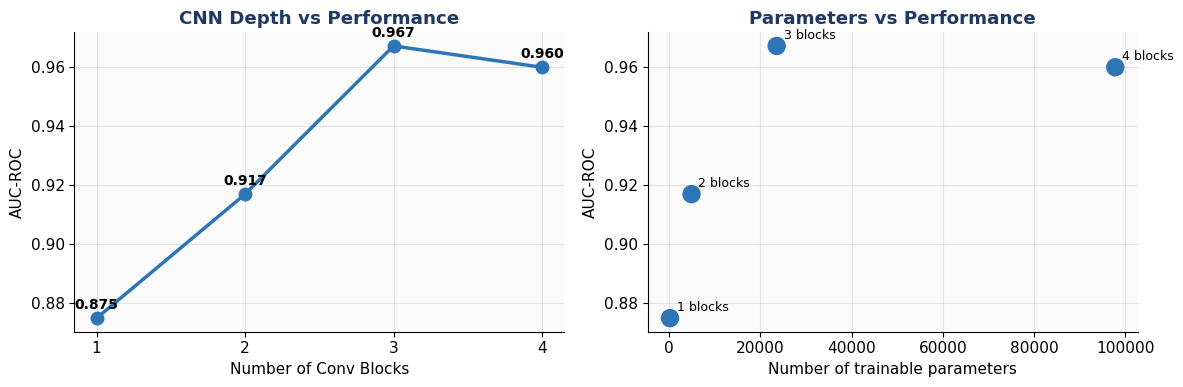


🔑 Key finding: Beyond 3 blocks, gains plateau but Grad-CAM spatial resolution DECREASES
   (feature maps shrink with each MaxPool). Clinical deployability requires balancing depth
   with explanation spatial resolution.


In [5]:
# ── 3a: Depth sweep (1–4 blocks) ─────────────────────────────────────────────
print("Running depth sweep (this takes ~3-5 minutes on CPU)...")
depth_results = {}
for n_blocks in [1, 2, 3, 4]:
    model = ClinicalCNN(n_blocks=n_blocks, base_filters=16, kernel_size=3)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nDepth {n_blocks} blocks | {n_params:,} parameters")
    train_cnn(model, tr_loader, n_epochs=12)
    res = evaluate_cnn(model, te_loader)
    depth_results[n_blocks] = {'auc': res['auc'], 'params': n_params, 'model': model}
    print(f"  AUC: {res['auc']:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
depths = list(depth_results.keys())
aucs = [depth_results[d]['auc'] for d in depths]
params = [depth_results[d]['params'] for d in depths]

ax1.plot(depths, aucs, 'o-', color=BLUE, lw=2.5, ms=9)
for d, a in zip(depths, aucs):
    ax1.text(d, a+0.003, f'{a:.3f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('Number of Conv Blocks'); ax1.set_ylabel('AUC-ROC')
ax1.set_title('CNN Depth vs Performance', fontweight='bold', color=NAVY)
ax1.set_xticks(depths); ax1.grid(alpha=0.3)

ax2.scatter(params, aucs, c=[BLUE]*len(depths), s=150, zorder=4)
for d, p, a in zip(depths, params, aucs):
    ax2.annotate(f'{d} blocks', (p, a), xytext=(5,5), textcoords='offset points', fontsize=9)
ax2.set_xlabel('Number of trainable parameters'); ax2.set_ylabel('AUC-ROC')
ax2.set_title('Parameters vs Performance', fontweight='bold', color=NAVY)
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

print("\n🔑 Key finding: Beyond 3 blocks, gains plateau but Grad-CAM spatial resolution DECREASES")
print("   (feature maps shrink with each MaxPool). Clinical deployability requires balancing depth")
print("   with explanation spatial resolution.")


---
## Section 4 — Grad-CAM Implementation from Scratch
🗂 **PneumoniaMNIST**

Grad-CAM (Selvaraju et al., 2017) uses gradient information flowing into a convolutional layer
to highlight the spatial regions that most influenced the classification decision.

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$

where $\alpha_k^c = \frac{1}{Z}\sum_{i,j} \frac{\partial y^c}{\partial A^k_{ij}}$


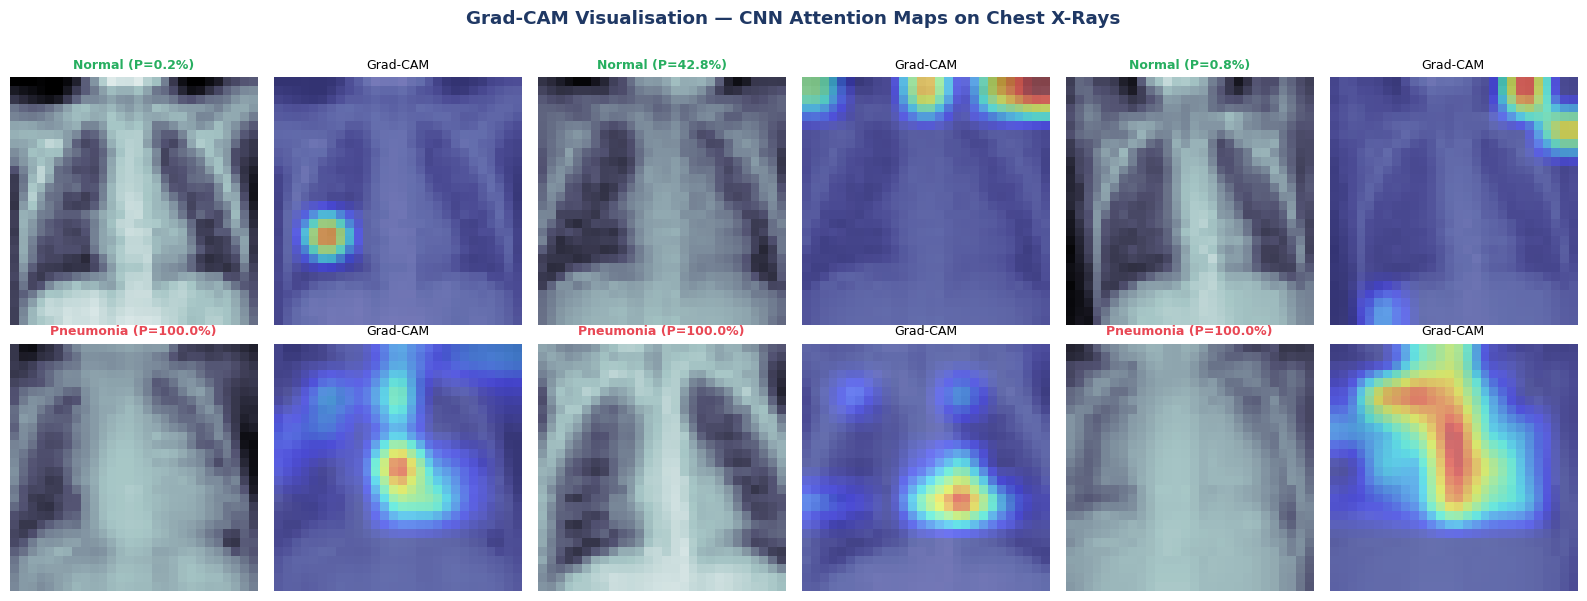

Red/yellow regions = areas the model focused on for its decision.
Clinical audit: verify that pneumonia maps highlight lung fields, NOT image corners or labels.


In [6]:
# ── Grad-CAM implementation ───────────────────────────────────────────────────
class GradCAM:
    """Grad-CAM for the ClinicalCNN model.
    
    Registers forward + backward hooks on a chosen conv block
    to capture activations and gradients.
    """
    def __init__(self, model, layer_idx=-1):
        self.model = model
        self.layer_idx = layer_idx if layer_idx >= 0 else model.n_blocks + layer_idx
        self.activations = None
        self.gradients = None
        # Register hooks on the chosen conv block
        target_layer = model.convs[self.layer_idx][0]  # the Conv2d layer
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)
    
    def _fwd_hook(self, module, input, output):
        self.activations = output.detach()
    
    def _bwd_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def compute(self, img_tensor, class_idx=None):
        """img_tensor: (1, C, H, W)  Returns: heatmap (H_orig, W_orig)"""
        self.model.eval()
        img_tensor = img_tensor.clone().requires_grad_(True).to(DEVICE)
        out, _ = self.model(img_tensor)
        score = torch.sigmoid(out.squeeze())
        self.model.zero_grad()
        score.backward()
        
        # Alpha = global average of gradients over spatial dims
        alpha = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam = (alpha * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H', W')
        cam = F.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        
        # Upsample to original image size
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        from PIL import Image
        import PIL
        cam_img = Image.fromarray((cam * 255).astype(np.uint8))
        cam_resized = np.array(cam_img.resize((28, 28), PIL.Image.BILINEAR)) / 255.0
        return cam_resized, score.item()

# ── Visualise Grad-CAM on test samples ────────────────────────────────────────
best_cnn = depth_results[3]['model'] if 3 in depth_results else cnn_default
gcam = GradCAM(best_cnn, layer_idx=-1)  # last conv block

# Pick 4 correctly classified examples (2 pneumonia, 2 normal)
best_cnn.eval()
pneum_correct = []; normal_correct = []
with torch.no_grad():
    for i in range(len(X_te)):
        img = X_te[i:i+1].to(DEVICE)
        out, _ = best_cnn(img)
        pred = int(torch.sigmoid(out.squeeze()) > 0.5)
        true = int(y_te[i])
        if true == 1 and pred == 1 and len(pneum_correct) < 3:  pneum_correct.append(i)
        if true == 0 and pred == 0 and len(normal_correct) < 3: normal_correct.append(i)
        if len(pneum_correct) == 3 and len(normal_correct) == 3: break

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("Grad-CAM Visualisation — CNN Attention Maps on Chest X-Rays", 
             fontweight='bold', color=NAVY, y=1.01)

for col, idx in enumerate(normal_correct):
    img = X_te[idx:idx+1]
    cam, prob = gcam.compute(img)
    img_np = img.squeeze().numpy()
    axes[0, col*2].imshow(img_np, cmap='bone', vmin=0, vmax=1)
    axes[0, col*2].set_title(f'Normal (P={prob:.1%})', color=GREEN, fontsize=9, fontweight='bold')
    axes[0, col*2].axis('off')
    axes[0, col*2+1].imshow(img_np, cmap='bone', vmin=0, vmax=1, alpha=0.6)
    axes[0, col*2+1].imshow(cam, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[0, col*2+1].set_title('Grad-CAM', fontsize=9); axes[0, col*2+1].axis('off')

for col, idx in enumerate(pneum_correct):
    img = X_te[idx:idx+1]
    cam, prob = gcam.compute(img)
    img_np = img.squeeze().numpy()
    axes[1, col*2].imshow(img_np, cmap='bone', vmin=0, vmax=1)
    axes[1, col*2].set_title(f'Pneumonia (P={prob:.1%})', color=RED, fontsize=9, fontweight='bold')
    axes[1, col*2].axis('off')
    axes[1, col*2+1].imshow(img_np, cmap='bone', vmin=0, vmax=1, alpha=0.6)
    axes[1, col*2+1].imshow(cam, cmap='jet', alpha=0.5, vmin=0, vmax=1)
    axes[1, col*2+1].set_title('Grad-CAM', fontsize=9); axes[1, col*2+1].axis('off')

plt.tight_layout(); plt.show(); plt.close()
print("Red/yellow regions = areas the model focused on for its decision.")
print("Clinical audit: verify that pneumonia maps highlight lung fields, NOT image corners or labels.")


---
## Section 5 — Layer-by-Layer Grad-CAM: What Does Each Layer 'See'?
🗂 **PneumoniaMNIST**

A critical experiment for clinical AI validation: Grad-CAM applied at different depths
shows that early layers capture low-level features (edges, textures) while deeper layers
capture semantically meaningful regions (consolidation areas, opacity patterns).


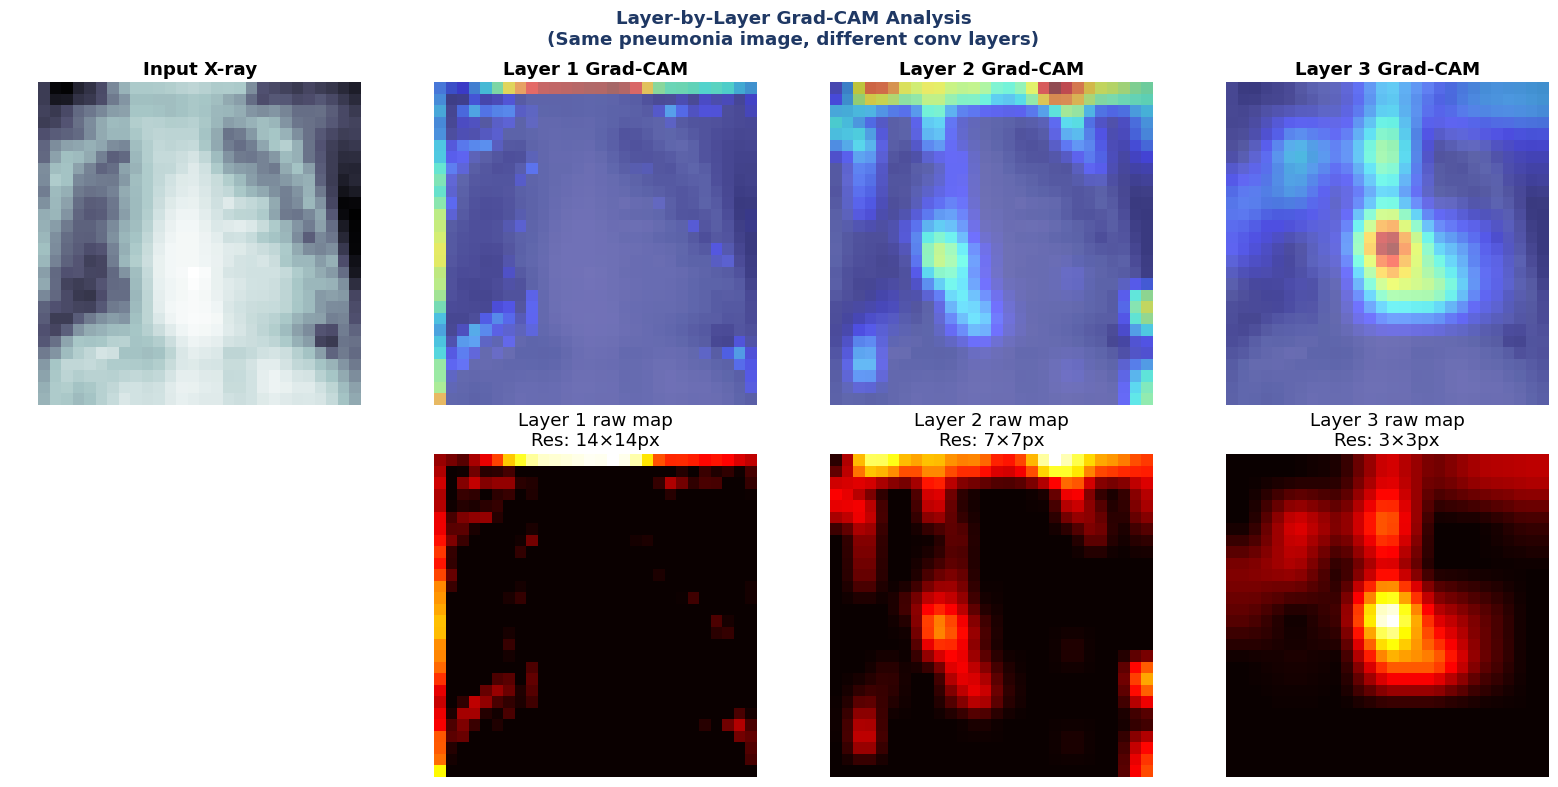

Observation: Early layers = diffuse, low-level. Late layers = focused, clinically meaningful.

⚠️  Clinical deployment rule: ALWAYS use the LAST conv layer for clinical Grad-CAM.
   Earlier layers produce diagnostically uninformative maps.


In [7]:
# ── Layer-by-layer Grad-CAM for one pneumonia image ──────────────────────────
if len(pneum_correct) > 0:
    sample_img = X_te[pneum_correct[0]:pneum_correct[0]+1]
    n_blocks_avail = best_cnn.n_blocks
    
    fig, axes = plt.subplots(2, n_blocks_avail+1, figsize=(4*(n_blocks_avail+1), 8))
    fig.suptitle("Layer-by-Layer Grad-CAM Analysis\n(Same pneumonia image, different conv layers)",
                 fontweight='bold', color=NAVY)
    
    # Row 1: Raw image + activation maps
    img_np = sample_img.squeeze().numpy()
    axes[0, 0].imshow(img_np, cmap='bone'); axes[0, 0].set_title('Input X-ray', fontweight='bold')
    axes[0, 0].axis('off')
    axes[1, 0].axis('off')
    
    for layer_i in range(n_blocks_avail):
        gcam_layer = GradCAM(best_cnn, layer_idx=layer_i)
        cam, prob = gcam_layer.compute(sample_img)
        # Show overlay
        axes[0, layer_i+1].imshow(img_np, cmap='bone', alpha=0.5)
        axes[0, layer_i+1].imshow(cam, cmap='jet', alpha=0.55)
        axes[0, layer_i+1].set_title(f'Layer {layer_i+1} Grad-CAM', fontweight='bold')
        axes[0, layer_i+1].axis('off')
        # Show raw CAM
        axes[1, layer_i+1].imshow(cam, cmap='hot')
        axes[1, layer_i+1].set_title(f'Layer {layer_i+1} raw map\nRes: {28//(2**(layer_i+1))}×{28//(2**(layer_i+1))}px')
        axes[1, layer_i+1].axis('off')
    
    plt.tight_layout(); plt.show(); plt.close()
    print("Observation: Early layers = diffuse, low-level. Late layers = focused, clinically meaningful.")
    print("\n⚠️  Clinical deployment rule: ALWAYS use the LAST conv layer for clinical Grad-CAM.")
    print("   Earlier layers produce diagnostically uninformative maps.")


---
## 📚 Paper Recommendations — Module 3 NB9

| # | Paper | Key contribution | 
|---|---|---|
| 1 | Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2017). Grad-cam: Visual explanations from deep networks via gradient-based localization. In Proceedings of the IEEE international conference on computer vision (pp. 618-626). | Original Grad-CAM algorithm | 
| 2 | He, F., Liu, T., & Tao, D. (2020). Why resnet works? residuals generalize. IEEE transactions on neural networks and learning systems, 31(12), 5349-5362. | Residual connections — why depth works | 
| 3 | Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017). Densely connected convolutional networks. In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 4700-4708). | Dense skip connections | 
| 4 | Tan, M., & Le, Q. (2019). Efficientnet: Rethinking model scaling for convolutional neural networks. In International conference on machine learning (pp. 6105-6114). PMLR. | Compound scaling | 
| 5 | Yang, J., Shi, R., Wei, D., Liu, Z., Zhao, L., Ke, B., ... & Ni, B. (2023). Medmnist v2-a large-scale lightweight benchmark for 2d and 3d biomedical image classification. Scientific data, 10(1), 41. | Medical imaging benchmarks | 